This notebook covers CLT and Z-scores

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

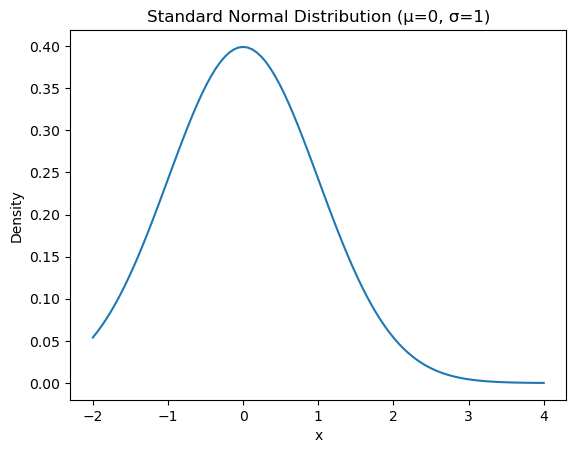

In [8]:
x = np.linspace(-2, 4, 100)
y = norm.pdf(x, loc=0, scale=1)
plt.plot(x, y)
plt.title("Standard Normal Distribution (μ=0, σ=1)")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

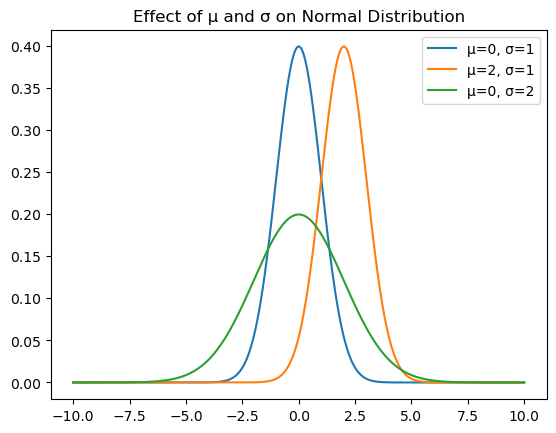

In [11]:
#How norm dist varies with mean and s.d.
x = np.linspace(-10, 10, 1000)

plt.plot(x, norm.pdf(x, 0, 1), label="μ=0, σ=1")
plt.plot(x, norm.pdf(x, 2, 1), label="μ=2, σ=1")
plt.plot(x, norm.pdf(x, 0, 2), label="μ=0, σ=2")

plt.legend()
plt.title("Effect of μ and σ on Normal Distribution")
plt.show()

In [13]:
# Manual Z-score
x_value = 85
mean = 70
std = 10

z = (x_value - mean) / std
print("Z-score:", z)

#Using SciPy
prob = norm.cdf(x_value, loc=mean, scale=std)
print("P(X ≤ 85):", prob)

Z-score: 1.5
P(X ≤ 85): 0.9331927987311419


In [16]:
#Critical values
value = norm.ppf(0.995, loc=0, scale=1)
print("Z critical value (99% CI):", value)

Z critical value (99% CI): 2.5758293035489004


In [17]:
value = norm.ppf(0.975, loc=0, scale=1)
print("Z critical value (95% CI):", value)

Z critical value (95% CI): 1.959963984540054


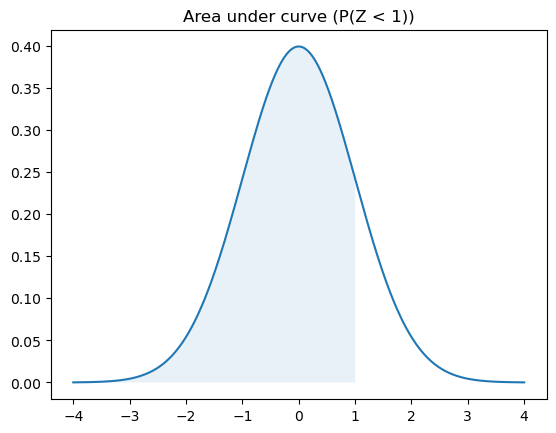

In [24]:
#Visualization
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.plot(x, y)

# Shade area for Z < 1
x_fill = np.linspace(-4, 1, 1000)
plt.fill_between(x_fill, norm.pdf(x_fill), alpha=0.1)

plt.title("Area under curve (P(Z < 1))")
plt.show()

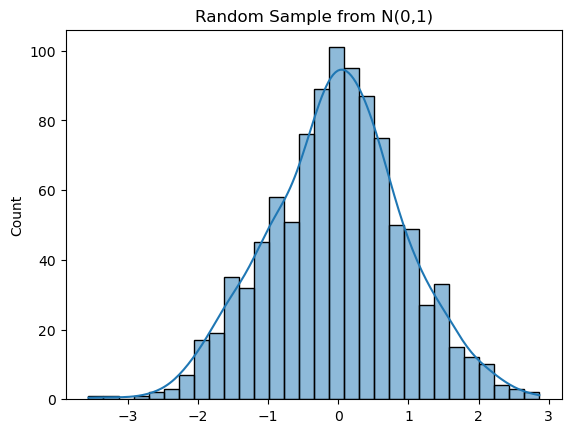

In [6]:
#Normal distriibution random sampling
data = norm.rvs(loc=0, scale=1, size=1000)
sns.histplot(data, bins=30, kde=True)
plt.title("Random Sample from N(0,1)")
plt.show()

### CLT Simulation 

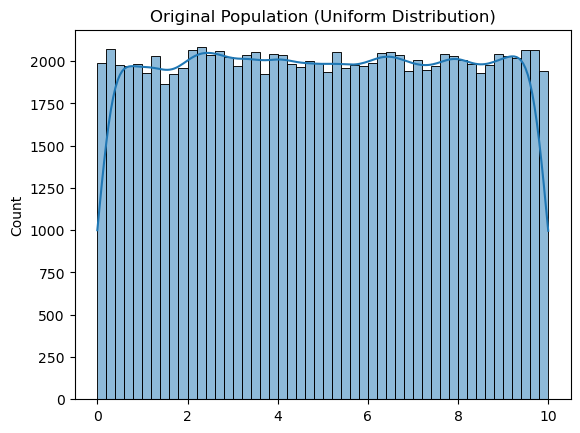

In [8]:
population = np.random.uniform(low=0, high=10, size=100000)

sns.histplot(population, bins=50, kde=True)
plt.title("Original Population (Uniform Distribution)")
plt.show()


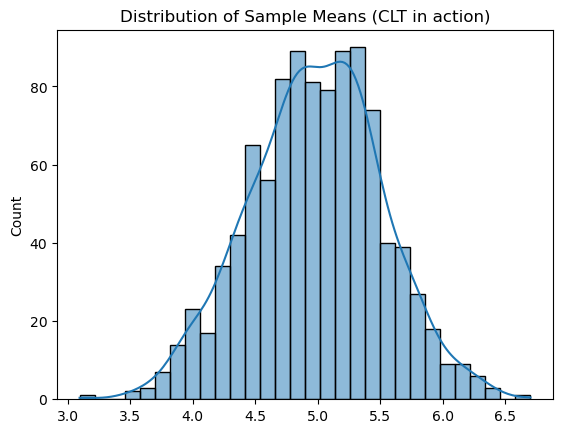

In [10]:
#sample means
sample_size = 30
num_samples = 1000

sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

sns.histplot(sample_means, bins=30, kde=True)
plt.title("Distribution of Sample Means (CLT in action)")
plt.show()

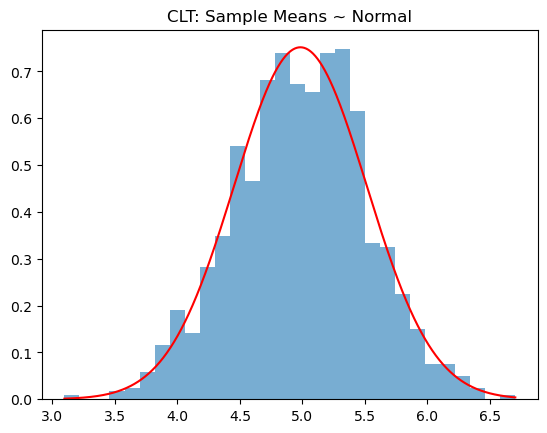

In [11]:
#Comparing with norm dist
mean = np.mean(sample_means)
std = np.std(sample_means)

x = np.linspace(min(sample_means), max(sample_means), 1000)

plt.hist(sample_means, bins=30, density=True, alpha=0.6)
plt.plot(x, norm.pdf(x, mean, std), 'r')

plt.title("CLT: Sample Means ~ Normal")
plt.show()

Effect of sample size

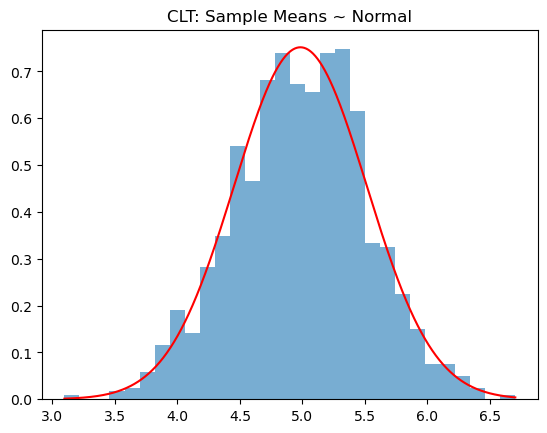

In [12]:
mean = np.mean(sample_means)
std = np.std(sample_means)

x = np.linspace(min(sample_means), max(sample_means), 1000)

plt.hist(sample_means, bins=30, density=True, alpha=0.6)
plt.plot(x, norm.pdf(x, mean, std), 'r')

plt.title("CLT: Sample Means ~ Normal")
plt.show()